# Spin spirals, without a supercell

A flat spiral turns the moment by $\mathbf q\cdot\mathbf R$ from cell to cell, so it is
periodic only if $\mathbf q$ is commensurate — and a supercell large enough for a general
one is out of reach. The generalized Bloch theorem removes the need: the up component of
the spinor lives at $\mathbf k + \mathbf q/2$ and the down at $\mathbf k - \mathbf q/2$,
each on its own plane-wave sphere, and in the rotated frame the density and the potential
are lattice periodic again — so the SCF, the functional and the mixer are untouched.

`pw.x` has no spin spiral, so the validation is **identities**: at the wavevectors where a
supercell *is* possible, the spiral must reproduce it. It does, to 1e-12 Ry. Phase P19,
following Elk.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso.io.pwin import parse_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import run_scf
from pypresso.scf.driver import Calculation
from pypresso.system import build_system
from pypresso.system.spiral import spiral_kpoints
from pypresso.workflows.spiral import heisenberg_exchange, run_spiral_scan

PSEUDO, GENERATED = Path("../tests/data/pseudo"), Path("../tests/data/qe")
RY_TO_MEV = 13.605693122994 * 1000.0
CHAIN = (GENERATED / "h-chain-spiral.in").read_text()


def load(text):
    system = build_system(parse_pw_input(text))
    return system, tuple(read_upf(PSEUDO / s.pseudo_file)
                         for s in system.structure.species)


def scf(text, **options):
    system, pseudos = load(text)
    pwin = parse_pw_input(text)
    options.setdefault("conv_thr", float(pwin.get("electrons", "conv_thr") or 1e-10))
    options.setdefault("mixing_beta", float(pwin.get("electrons", "mixing_beta") or 0.7))
    options.setdefault("max_iterations", 200)
    return system, run_scf(system, pseudos, **options)


def at_q(q3):
    return CHAIN.replace("spiral_q(3) = 0.25", f"spiral_q(3) = {q3}")


def electronic(result):
    """The total energy without Ewald, which two different cells disagree on."""
    return result.total_energy - result.energy_terms["ewald"]


# A hydrogen chain, one atom per cell, spiralling along z.
system, pseudos = load(at_q(0.25))
doubled = spiral_kpoints(system.kpoints, system.spiral_q, system.cell)
calculation = Calculation(system, pseudos)
npw, nk = calculation.basis.planewaves.npw, system.kpoints.nk

print("%26s  %10s %12s" % ("k (2pi/alat)", "centre", "plane waves"))
for row in range(2 * nk):
    print("%26s  %10s %12d"
          % (np.round(np.asarray(doubled.coords[row]), 4),
             "k + q/2" if row < nk else "k - q/2", npw[row]))
print("\nthe two components differ by up to %d plane waves at the same k-point; both are "
      "padded to npwx = %d and masked."
      % (max(abs(npw[i] - npw[i + nk]) for i in range(nk)),
         calculation.basis.planewaves.npwx))

              k (2pi/alat)      centre  plane waves
             [0.  0.  0.3]     k + q/2         1524
             [0.  0.  0.9]     k + q/2         1532
          [ 0.   0.  -0.9]     k + q/2         1532
          [ 0.   0.  -0.3]     k + q/2         1524
          [ 0.   0.  -0.3]     k - q/2         1524
             [0.  0.  0.3]     k - q/2         1524
          [ 0.   0.  -1.5]     k - q/2         1532
          [ 0.   0.  -0.9]     k - q/2         1532

the two components differ by up to 8 plane waves at the same k-point; both are padded to npwx = 1532 and masked.


## The three identities that validate it

**$q = 0$** is not a spiral and must not behave like one: it has to reproduce an ordinary
noncollinear run exactly. **$q = b_3/2$** turns the moment by 180 degrees per cell, which
is the antiferromagnet the *collinear* code can do in a doubled cell. **$q = b_3/4$** is a
quarter turn, which is a four-cell noncollinear supercell.

Only the electronic energy is compared for the last two: the Ewald sum of a one-atom cell
and of its supercell are genuinely different numbers, and per atom they agree anyway.

In [2]:
atom = (GENERATED / "h-atom-lsda.in").read_text()
noncollinear = atom.replace(
    "    nspin = 2",
    "    noncolin = .true.\n    nosym = .true.\n    angle1(1) = 90.0")
_, plain = scf(noncollinear)
_, zero = scf(noncollinear.replace(
    "    nosym = .true.",
    "    nosym = .true.\n    spiral_q(1) = 0.0, spiral_q(2) = 0.0, spiral_q(3) = 0.0"))
print("q = 0 against an ordinary noncollinear run   %.1e Ry"
      % abs(zero.total_energy - plain.total_energy))

_, spiral_half = scf(at_q(0.5))
_, afm = scf((GENERATED / "h-chain-afm.in").read_text())
print("q = b3/2 against the collinear antiferromagnet %.1e Ry"
      % abs(electronic(spiral_half) - electronic(afm) / 2))

_, spiral_quarter = scf(at_q(0.25))
_, ninety = scf((GENERATED / "h-chain-90deg.in").read_text())
print("q = b3/4 against a four-cell 90-degree supercell %.1e Ry"
      % abs(electronic(spiral_quarter) - electronic(ninety) / 4))

q = 0 against an ordinary noncollinear run   5.6e-16 Ry


q = b3/2 against the collinear antiferromagnet 7.4e-13 Ry


q = b3/4 against a four-cell 90-degree supercell 2.9e-12 Ry


**The trap of the phase.** A supercell built to hold the spiral has its own k-grid, and
the two calculations only agree if that grid is the *shifted* one the folding demands —
comparing against the unshifted grid gives a plausible number that is wrong in the fourth
decimal.

## `E(q)`: the frozen-magnon dispersion

Scanning $q$ costs one SCF per point and no supercell at all, which is the whole reason
the theorem is worth implementing. The curve falls away from $q = 0$, so the chain is an
antiferromagnet; fitting a Heisenberg model to it gives the exchange constants.

J1 = -112.428 meV (5 bohr)   J2 = +29.033 meV (10 bohr)
largest residual of the two-shell fit  0.814 meV  (2.2% of the curve)
all 11 points converged: True


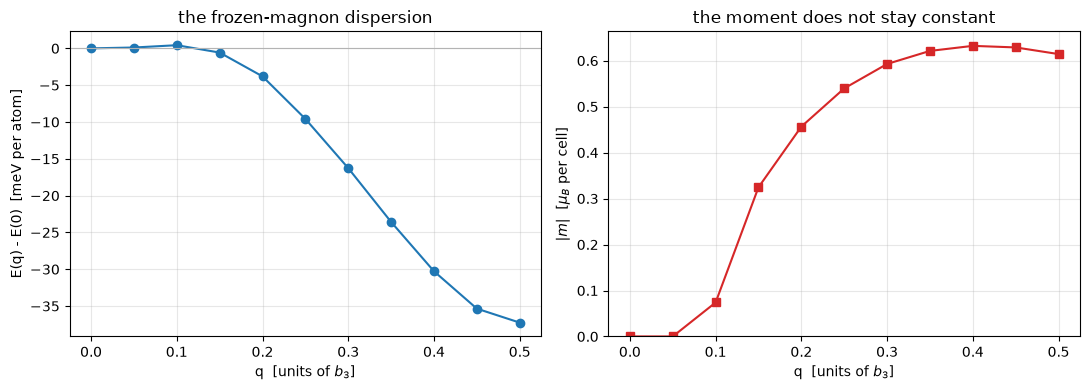

In [3]:
system, pseudos = load(at_q(0.0))
scan = run_spiral_scan(system, pseudos, [[0.0, 0.0, q] for q in np.linspace(0, 0.5, 11)],
                       conv_thr=1e-10, mixing_beta=0.3, max_iterations=200)

q = scan.wavevectors[:, 2]
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.plot(q, (scan.energies - scan.energies[0]) * RY_TO_MEV, "o-", color="tab:blue")
left.axhline(0.0, color="0.7", lw=0.8)
left.set_xlabel("q  [units of $b_3$]"); left.set_ylabel("E(q) - E(0)  [meV per atom]")
left.set_title("the frozen-magnon dispersion")
right.plot(q, np.linalg.norm(scan.moments, axis=1), "s-", color="tab:red")
right.set_xlabel("q  [units of $b_3$]"); right.set_ylabel(r"$|m|$  [$\mu_B$ per cell]")
right.set_title("the moment does not stay constant"); right.set_ylim(bottom=0.0)
for axis in (left, right):
    axis.grid(alpha=0.3)
fig.tight_layout()

shells = [[0.0, 0.0, 1.0], [0.0, 0.0, 2.0]]        # nearest and next-nearest
J = heisenberg_exchange(scan, system.cell, shells)
model = sum(J[n] * (1.0 - np.cos(2.0 * np.pi * q * (n + 1))) for n in range(len(shells)))
model = model * np.mean(np.linalg.norm(scan.moments, axis=1)) ** 2
residual = np.max(np.abs(model - (scan.energies - scan.energies[0])))
print("J1 = %+.3f meV (5 bohr)   J2 = %+.3f meV (10 bohr)"
      % (J[0] * RY_TO_MEV, J[1] * RY_TO_MEV))
print("largest residual of the two-shell fit  %.3f meV  (%.1f%% of the curve)"
      % (residual * RY_TO_MEV,
         100 * residual / max(abs(scan.energies - scan.energies[0]))))
print("all %d points converged: %s" % (len(q), bool(np.all(scan.converged))))

A negative $J_1$ is antiferromagnetic in the convention $H = -\sum J_{ij}\,
\mathbf e_i\cdot\mathbf e_j$, which is what a curve falling away from $q = 0$ must give.

**The moment is a gauge and the energy is not.** Running at $q$ and at $q + b_3$ gives the
same energy to 1e-10 Ry and a different cell-integrated moment: the rotated frame is a
choice, and only frame-independent quantities are physical.

**Three things a spiral refuses.** Spin-orbit coupling, permanently — it breaks the
theorem, and Elk refuses it too. Symmetry, until the spin space group is written, so a
spiral needs `nosym` and the full k-grid. And ultrasoft/PAW, until the augmentation charge
*between the two components* is threaded through.

---
**The detail:** `PLAN.md` §3 P19. Notebook 14 relaxes $q$ itself down `dE/dq`.
**The tests:** `tests/regression/test_spin_spirals.py`.